In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, ttest_ind

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('calcium_data.csv')
print(df.shape)
df.head(10)

(49, 7)


,source,year,milk_type,treatment,temperature_C,calcium_activity_mM,pH
0,foods2023,2023,bovine_skim,none,0,1.02,6.83
1,foods2023,2023,bovine_skim,none,85,0.95,6.81
2,foods2023,2023,bovine_skim,none,95,0.91,6.79
3,foods2023,2023,bovine_skim,TSC,0,0.73,7.02
4,foods2023,2023,bovine_skim,TSC,85,0.69,6.97
5,foods2023,2023,bovine_skim,TSC,95,0.67,6.93
6,foods2023,2023,bovine_skim,DSHP,0,0.73,6.95
7,foods2023,2023,bovine_skim,DSHP,85,0.64,6.91
8,foods2023,2023,bovine_skim,DSHP,95,0.62,6.89
9,foods2023,2023,buffalo_skim,none,0,0.84,6.93


In [2]:
print(df[['temperature_C','calcium_activity_mM','pH']].describe().round(3))

control = df[(df['treatment'] == 'none') & (df['calcium_activity_mM'] < 20)]
print(control.groupby('temperature_C')['calcium_activity_mM'].mean().round(3))
print(control.groupby('milk_type')['calcium_activity_mM'].mean().round(3))

       temperature_C  calcium_activity_mM      pH
count         49.000               49.000  34.000
mean          64.143               52.478   6.771
std           40.354              104.412   0.219
min            0.000                0.420   6.240
25%           20.000                0.670   6.635
50%           80.000                0.950   6.835
75%           95.000               94.000   6.930
max          135.000              450.200   7.080
temperature_C
0      0.970
20     2.060
40     1.050
60     0.880
66     2.880
77     1.050
80     0.650
82     2.500
85     0.900
90     0.550
95     0.867
100    0.480
110    0.420
Name: calcium_activity_mM, dtype: float64
milk_type
blend_50_50         0.897
bovine_semi_skim    0.750
bovine_skim         1.860
buffalo_skim        0.837
cow                 1.075
Name: calcium_activity_mM, dtype: float64


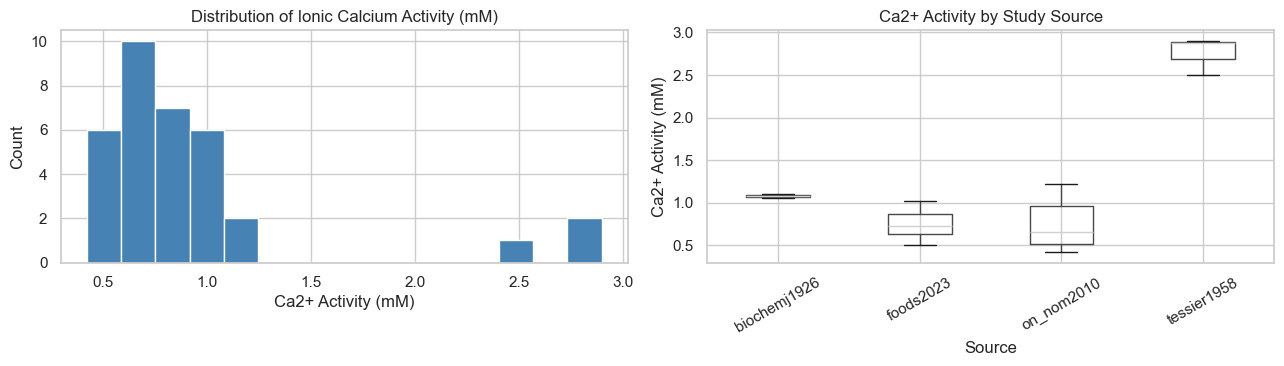

In [3]:
mM_data = df[(df['calcium_activity_mM'].notna()) & (df['calcium_activity_mM'] < 20)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

mM_data['calcium_activity_mM'].hist(bins=15, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Ionic Calcium Activity (mM)')
axes[0].set_xlabel('Ca2+ Activity (mM)')
axes[0].set_ylabel('Count')

mM_data.boxplot(column='calcium_activity_mM', by='source', ax=axes[1])
axes[1].set_title('Ca2+ Activity by Study Source')
axes[1].set_xlabel('Source')
axes[1].set_ylabel('Ca2+ Activity (mM)')
plt.suptitle('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

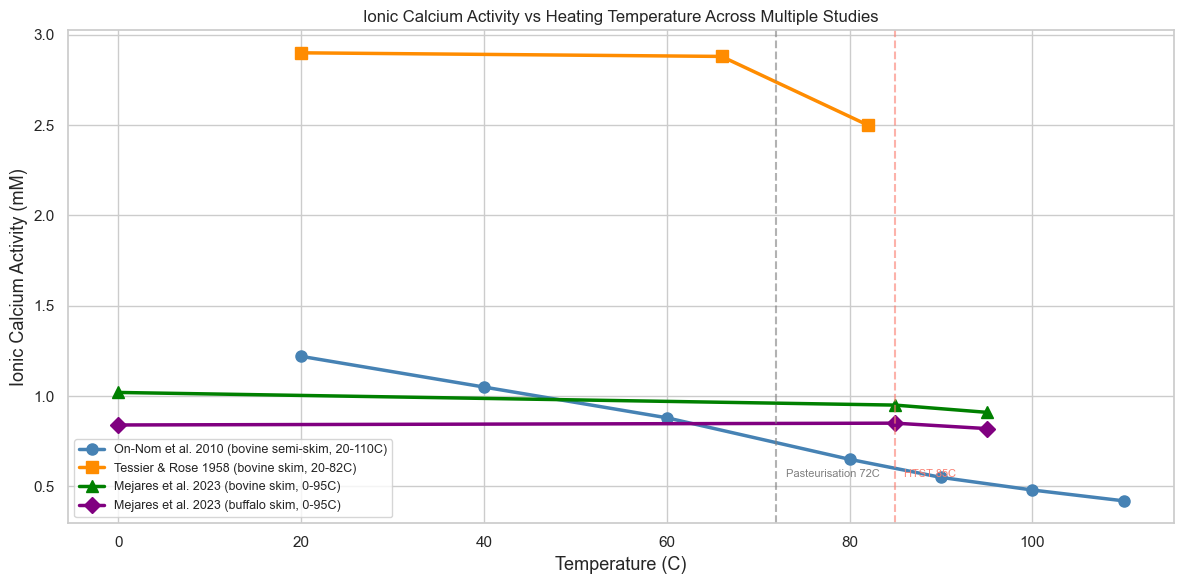

In [4]:
mM_sources = ['on_nom2010', 'tessier1958', 'foods2023']
plot_data = df[
    (df['source'].isin(mM_sources)) &
    (df['treatment'] == 'none') &
    (df['calcium_activity_mM'].notna()) &
    (df['calcium_activity_mM'] < 20)
]

fig, ax = plt.subplots(figsize=(12, 6))

sub = plot_data[plot_data['source'] == 'on_nom2010'].sort_values('temperature_C')
ax.plot(sub['temperature_C'], sub['calcium_activity_mM'], marker='o', color='steelblue',
        linewidth=2.5, markersize=8, label='On-Nom et al. 2010 (bovine semi-skim, 20-110C)')

sub = plot_data[plot_data['source'] == 'tessier1958'].sort_values('temperature_C')
ax.plot(sub['temperature_C'], sub['calcium_activity_mM'], marker='s', color='darkorange',
        linewidth=2.5, markersize=8, label='Tessier & Rose 1958 (bovine skim, 20-82C)')

sub = plot_data[(plot_data['source'] == 'foods2023') & (plot_data['milk_type'] == 'bovine_skim')].sort_values('temperature_C')
ax.plot(sub['temperature_C'], sub['calcium_activity_mM'], marker='^', color='green',
        linewidth=2.5, markersize=8, label='Mejares et al. 2023 (bovine skim, 0-95C)')

sub = plot_data[(plot_data['source'] == 'foods2023') & (plot_data['milk_type'] == 'buffalo_skim')].sort_values('temperature_C')
ax.plot(sub['temperature_C'], sub['calcium_activity_mM'], marker='D', color='purple',
        linewidth=2.5, markersize=8, label='Mejares et al. 2023 (buffalo skim, 0-95C)')

ax.axvline(x=72, color='gray', linestyle='--', alpha=0.6, linewidth=1.5)
ax.text(73, 0.55, 'Pasteurisation 72C', fontsize=8, color='gray')
ax.axvline(x=85, color='salmon', linestyle='--', alpha=0.6, linewidth=1.5)
ax.text(86, 0.55, 'HTST 85C', fontsize=8, color='salmon')

ax.set_xlabel('Temperature (C)', fontsize=13)
ax.set_ylabel('Ionic Calcium Activity (mM)', fontsize=13)
ax.set_title('Ionic Calcium Activity vs Heating Temperature Across Multiple Studies')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

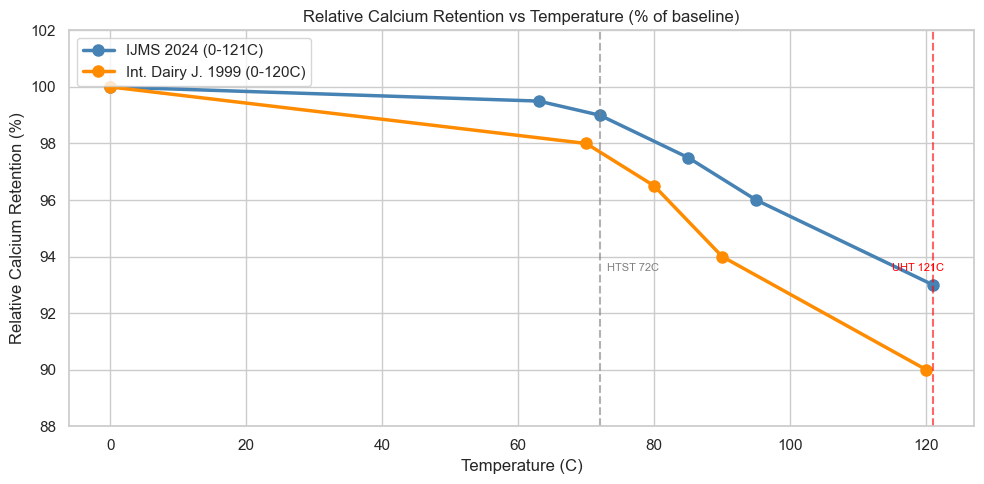

In [5]:
pct_sources = ['ijms2024', 'intdairy1999']
pct_data = df[
    (df['source'].isin(pct_sources)) &
    (df['treatment'] == 'none') &
    (df['calcium_activity_mM'].notna())
]

fig, ax = plt.subplots(figsize=(10, 5))

for src, color, label in [
    ('ijms2024', 'steelblue', 'IJMS 2024 (0-121C)'),
    ('intdairy1999', 'darkorange', 'Int. Dairy J. 1999 (0-120C)')
]:
    sub = pct_data[pct_data['source'] == src].sort_values('temperature_C')
    ax.plot(sub['temperature_C'], sub['calcium_activity_mM'], marker='o',
            color=color, linewidth=2.5, markersize=8, label=label)

ax.axvline(x=72, color='gray', linestyle='--', alpha=0.6)
ax.text(73, 93.5, 'HTST 72C', fontsize=8, color='gray')
ax.axvline(x=121, color='red', linestyle='--', alpha=0.6)
ax.text(115, 93.5, 'UHT 121C', fontsize=8, color='red')

ax.set_xlabel('Temperature (C)', fontsize=12)
ax.set_ylabel('Relative Calcium Retention (%)', fontsize=12)
ax.set_title('Relative Calcium Retention vs Temperature (% of baseline)')
ax.legend()
ax.set_ylim(88, 102)

plt.tight_layout()
plt.show()

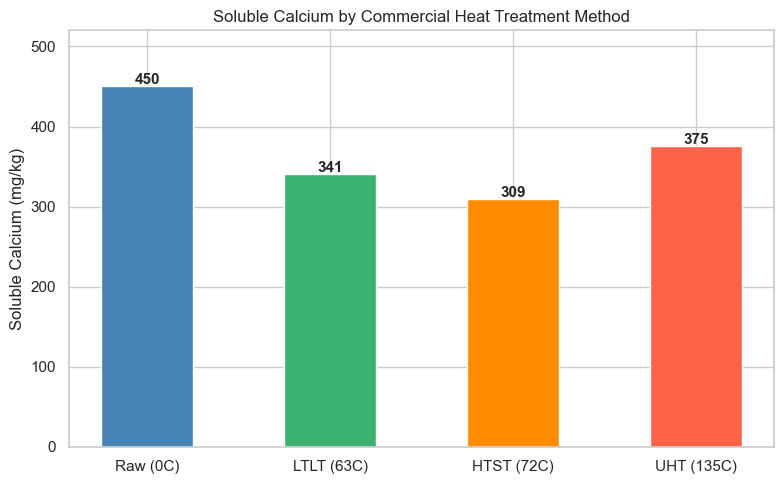

In [6]:
korea = df[df['source'] == 'korea2013'].copy()
labels = ['Raw (0C)', 'LTLT (63C)', 'HTST (72C)', 'UHT (135C)']
values = korea['calcium_activity_mM'].values

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=['steelblue', 'mediumseagreen', 'darkorange', 'tomato'],
              edgecolor='white', width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{val:.0f}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Soluble Calcium (mg/kg)', fontsize=12)
ax.set_title('Soluble Calcium by Commercial Heat Treatment Method')
ax.set_ylim(0, 520)

plt.tight_layout()
plt.show()

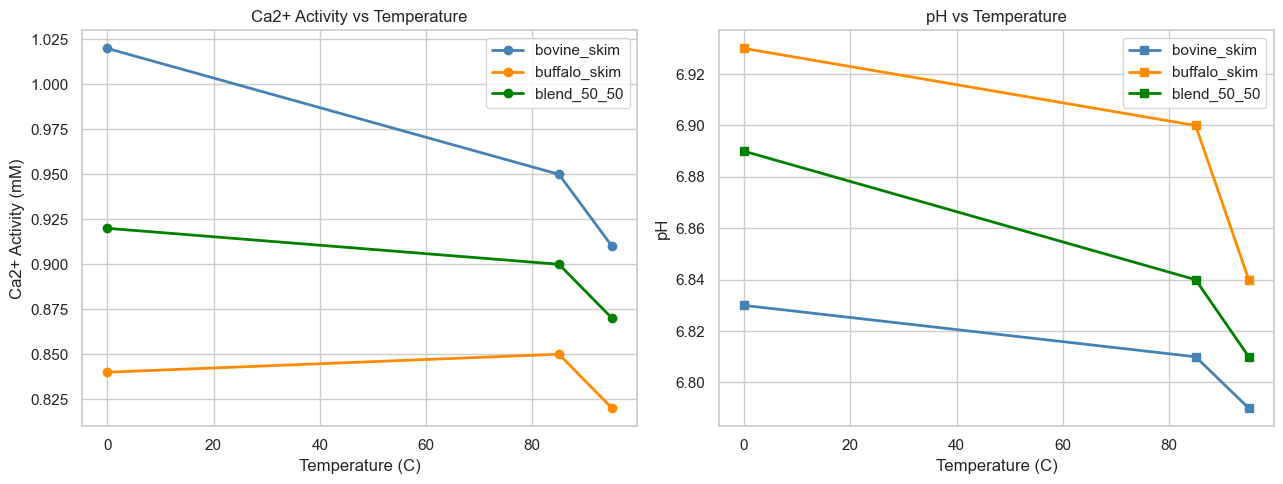

In [7]:
foods_control = df[(df['source'] == 'foods2023') & (df['treatment'] == 'none')]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

milk_colors = {'bovine_skim': 'steelblue', 'buffalo_skim': 'darkorange', 'blend_50_50': 'green'}
for milk in ['bovine_skim', 'buffalo_skim', 'blend_50_50']:
    sub = foods_control[foods_control['milk_type'] == milk].sort_values('temperature_C')
    axes[0].plot(sub['temperature_C'], sub['calcium_activity_mM'], marker='o',
                 color=milk_colors[milk], linewidth=2, label=milk)
    axes[1].plot(sub['temperature_C'], sub['pH'], marker='s',
                 color=milk_colors[milk], linewidth=2, label=milk)

axes[0].set_title('Ca2+ Activity vs Temperature')
axes[0].set_xlabel('Temperature (C)')
axes[0].set_ylabel('Ca2+ Activity (mM)')
axes[0].legend()

axes[1].set_title('pH vs Temperature')
axes[1].set_xlabel('Temperature (C)')
axes[1].set_ylabel('pH')
axes[1].legend()

plt.tight_layout()
plt.show()

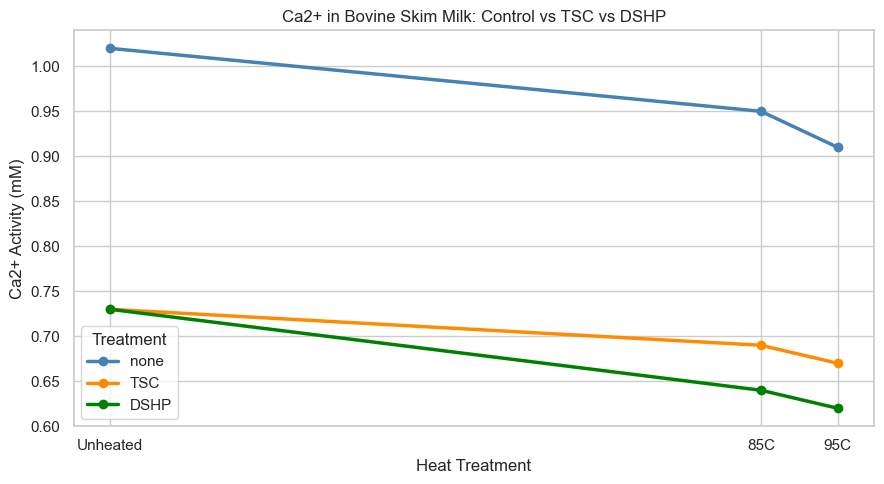

In [8]:
foods_bovine = df[(df['source'] == 'foods2023') & (df['milk_type'] == 'bovine_skim')]

fig, ax = plt.subplots(figsize=(9, 5))
colors = {'none': 'steelblue', 'TSC': 'darkorange', 'DSHP': 'green'}

for treatment in ['none', 'TSC', 'DSHP']:
    sub = foods_bovine[foods_bovine['treatment'] == treatment].sort_values('temperature_C')
    ax.plot(sub['temperature_C'], sub['calcium_activity_mM'],
            marker='o', linewidth=2.5, color=colors[treatment], label=treatment)

ax.set_xticks([0, 85, 95])
ax.set_xticklabels(['Unheated', '85C', '95C'])
ax.set_xlabel('Heat Treatment')
ax.set_ylabel('Ca2+ Activity (mM)')
ax.set_title('Ca2+ in Bovine Skim Milk: Control vs TSC vs DSHP')
ax.legend(title='Treatment')

plt.tight_layout()
plt.show()

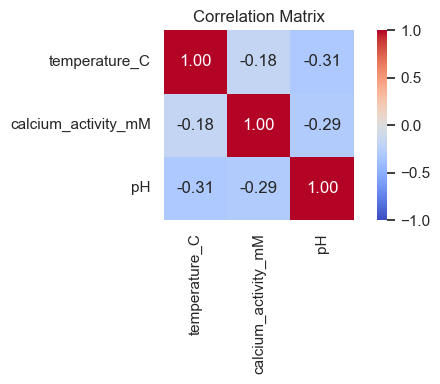

In [9]:
numeric_df = df[['temperature_C', 'calcium_activity_mM', 'pH']].dropna()
numeric_df = numeric_df[numeric_df['calcium_activity_mM'] < 20]

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [10]:
control_mM = df[
    (df['treatment'] == 'none') &
    (df['calcium_activity_mM'].notna()) &
    (df['calcium_activity_mM'] < 20)
]

groups = [g['calcium_activity_mM'].values
          for _, g in control_mM.groupby('temperature_C')
          if len(g) >= 1]

f_stat, p_value = f_oneway(*groups)
print(f'ANOVA  F={f_stat:.4f}  p={p_value:.6f}')
print('REJECT H0' if p_value < 0.05 else 'FAIL TO REJECT H0')

ANOVA  F=3.9783  p=0.029265
REJECT H0


In [11]:
low_temp  = control_mM[control_mM['temperature_C'] <= 20]['calcium_activity_mM'].values
high_temp = control_mM[control_mM['temperature_C'] >= 90]['calcium_activity_mM'].values

t_stat, p_val = ttest_ind(low_temp, high_temp)
print(f'Low temp mean  : {low_temp.mean():.3f} mM  (n={len(low_temp)})')
print(f'High temp mean : {high_temp.mean():.3f} mM  (n={len(high_temp)})')
print(f'Reduction      : {((low_temp.mean()-high_temp.mean())/low_temp.mean()*100):.1f}%')
print(f't={t_stat:.4f}  p={p_val:.6f}')
print('REJECT H0' if p_val < 0.05 else 'FAIL TO REJECT H0')

Low temp mean  : 1.333 mM  (n=6)
High temp mean : 0.675 mM  (n=6)
Reduction      : 49.4%
t=1.9949  p=0.074011
FAIL TO REJECT H0


In [12]:
corr_data = control_mM[['temperature_C', 'calcium_activity_mM']].dropna()
r, p = stats.pearsonr(corr_data['temperature_C'], corr_data['calcium_activity_mM'])
print(f'Pearson r={r:.4f}  p={p:.6f}')
strength = 'strong' if abs(r) > 0.7 else 'moderate' if abs(r) > 0.4 else 'weak'
print(f'{"negative" if r < 0 else "positive"} {strength} correlation')

Pearson r=-0.2338  p=0.307625
negative weak correlation


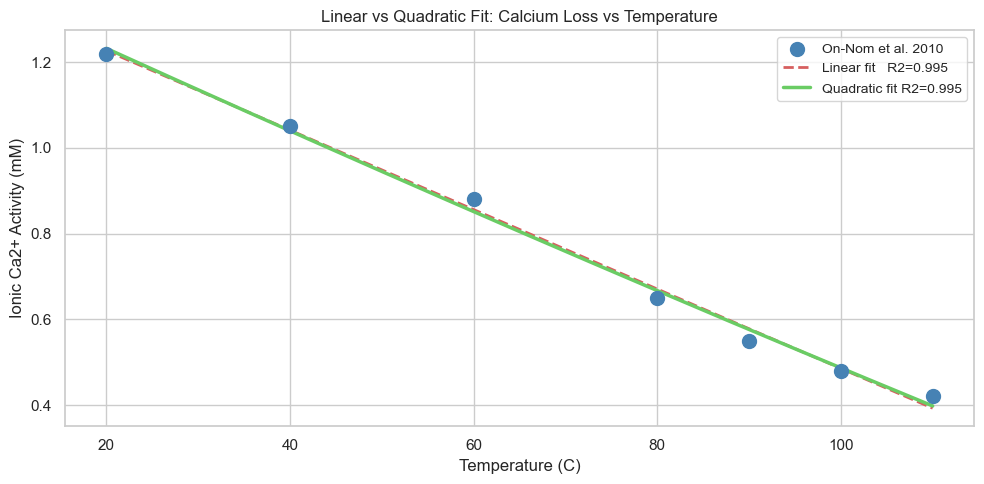

Linear R2=0.9952  Quadratic R2=0.9954
Quadratic better


In [13]:
fit_data = df[(df['source'] == 'on_nom2010') & (df['treatment'] == 'none')].dropna(subset=['calcium_activity_mM'])
x = fit_data['temperature_C'].values
y = fit_data['calcium_activity_mM'].values

lin_coef  = np.polyfit(x, y, 1)
lin_fit   = np.poly1d(lin_coef)
lin_r2    = np.corrcoef(y, lin_fit(x))[0,1]**2

quad_coef = np.polyfit(x, y, 2)
quad_fit  = np.poly1d(quad_coef)
quad_r2   = np.corrcoef(y, quad_fit(x))[0,1]**2

x_plot = np.linspace(x.min(), x.max(), 300)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x, y, color='steelblue', s=100, zorder=5, label='On-Nom et al. 2010')
ax.plot(x_plot, lin_fit(x_plot),  'r--', linewidth=2,   label=f'Linear fit   R2={lin_r2:.3f}')
ax.plot(x_plot, quad_fit(x_plot), 'g-',  linewidth=2.5, label=f'Quadratic fit R2={quad_r2:.3f}')
ax.set_xlabel('Temperature (C)', fontsize=12)
ax.set_ylabel('Ionic Ca2+ Activity (mM)', fontsize=12)
ax.set_title('Linear vs Quadratic Fit: Calcium Loss vs Temperature')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Linear R2={lin_r2:.4f}  Quadratic R2={quad_r2:.4f}')
print('Quadratic better' if quad_r2 > lin_r2 else 'Linear better')